# Data understanding and preparation

The aim of this part is to extract some important features from the dataset `Procedure_codes`, in order to build insights for the patient profile. 
This notebook is divided in two parts: 
<ul>
    <li><b>Data understanding</b></li>
    <li><b>Data Preparation</b></li>
</ul>

Before diving into the further steps, ensure to have installed the data analitycs libraries: 

In [1]:
%conda install pandas scipy seaborn 

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.9.1
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


## Data understanding

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

notebook_dir = Path().resolve()
data_path = notebook_dir.parents[1] / "1" / "Data" / "procedure_code_4.csv"
df = pd.read_csv(data_path)

In [3]:
df.shape

(14497, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14497 entries, 0 to 14496
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   subject_id  14497 non-null  int64 
 1   hadm_id     14497 non-null  int64 
 2   seq_num     14497 non-null  int64 
 3   chartdate   14497 non-null  object
 4   icd_code    14497 non-null  object
 5   long_title  14497 non-null  object
dtypes: int64(3), object(3)
memory usage: 679.7+ KB


## Data cleaning
We estimate the percentage of *missing values* contained in each column. 

In [5]:
for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / len(df)) * 100
    print(f"Column '{col}': {missing_percentage:.2f}% missing values")

Column 'subject_id': 0.00% missing values
Column 'hadm_id': 0.00% missing values
Column 'seq_num': 0.00% missing values
Column 'chartdate': 0.00% missing values
Column 'icd_code': 0.00% missing values
Column 'long_title': 0.00% missing values


Now, we estimate the types hiddenly taken by each columns

In [6]:
for col in df.columns:
    print (f"{col}: {df[col].map(type).value_counts()}")

subject_id: subject_id
<class 'int'>    14497
Name: count, dtype: int64
hadm_id: hadm_id
<class 'int'>    14497
Name: count, dtype: int64
seq_num: seq_num
<class 'int'>    14497
Name: count, dtype: int64
chartdate: chartdate
<class 'str'>    14497
Name: count, dtype: int64
icd_code: icd_code
<class 'str'>    14497
Name: count, dtype: int64
long_title: long_title
<class 'str'>    14497
Name: count, dtype: int64


We have no missing values on this dataFrame.


## Data Preparation

Check if we have duplicated records

In [7]:
print(df.shape)
df.drop_duplicates(inplace=True)
print(df.shape)

(14497, 6)
(14497, 6)


### Standardization

In [8]:
df['chartdate'] = pd.to_datetime(df['chartdate'])

In [9]:
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].str.strip()   
    df[col] = df[col].astype('string')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14497 entries, 0 to 14496
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   subject_id  14497 non-null  int64         
 1   hadm_id     14497 non-null  int64         
 2   seq_num     14497 non-null  int64         
 3   chartdate   14497 non-null  datetime64[ns]
 4   icd_code    14497 non-null  string        
 5   long_title  14497 non-null  string        
dtypes: datetime64[ns](1), int64(3), string(2)
memory usage: 679.7 KB


Now the records are standardized

### Data distributions

<Axes: xlabel='icd_code', ylabel='count'>

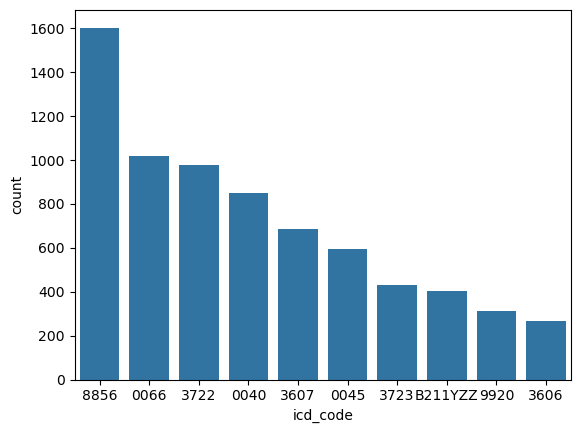

In [11]:
import seaborn as sns

icd_codes = df['icd_code'].value_counts().reset_index()
sns.barplot(data=icd_codes.head(10),
            x='icd_code',
            y='count', 
            )

### Feature extraction

We extract the features at admission level for the moment. 

In `patient_profile_creation` we aggregate this measures to create the patient profiles.

In [ ]:
# hadm_id aggregation: total count of procedures and procedure variety
proc_features = (
    df
    .groupby(['subject_id', 'hadm_id'])
    .agg(
        total_procedures=('icd_code', 'size'), # count
        unique_procedures=('icd_code', 'nunique'), # variety
        procedures_days_span=('chartdate', lambda x: (x.max() - x.min()).days)  # time span from first to last procedure of the admission
    )
    .reset_index()
)

print(f"Feature summary:\n{proc_features.describe()}")
proc_features.head(10)

Feature summary:
         subject_id       hadm_id  total_procedures  unique_procedures  \
count  3.459000e+03  3.459000e+03       3459.000000        3459.000000   
mean   1.499381e+07  2.502943e+07          4.191096           4.058398   
std    2.868527e+06  2.853466e+06          2.989024           2.717689   
min    1.000098e+07  2.000790e+07          1.000000           1.000000   
25%    1.249509e+07  2.264270e+07          2.000000           2.000000   
50%    1.495295e+07  2.506423e+07          3.000000           3.000000   
75%    1.747168e+07  2.747180e+07          6.000000           6.000000   
max    1.999850e+07  2.999967e+07         28.000000          21.000000   

       procedures_days_span  
count           3459.000000  
mean               1.442324  
std                3.541510  
min                0.000000  
25%                0.000000  
50%                0.000000  
75%                1.000000  
max               43.000000  


,subject_id,hadm_id,total_procedures,unique_procedures,procedures_days_span
0,10000980,26913865,7,7,0
1,10002013,24760295,2,2,0
2,10002155,23822395,8,8,14
3,10007058,22954658,2,2,0
4,10010424,28388172,5,5,0
5,10012343,27658045,8,8,0
6,10017531,20668418,8,8,4
7,10017886,20015927,2,2,0
8,10023117,28872262,6,6,5
9,10024913,27207228,9,9,0


## Features transformations

/tmp/ipykernel_26859/4197218523.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


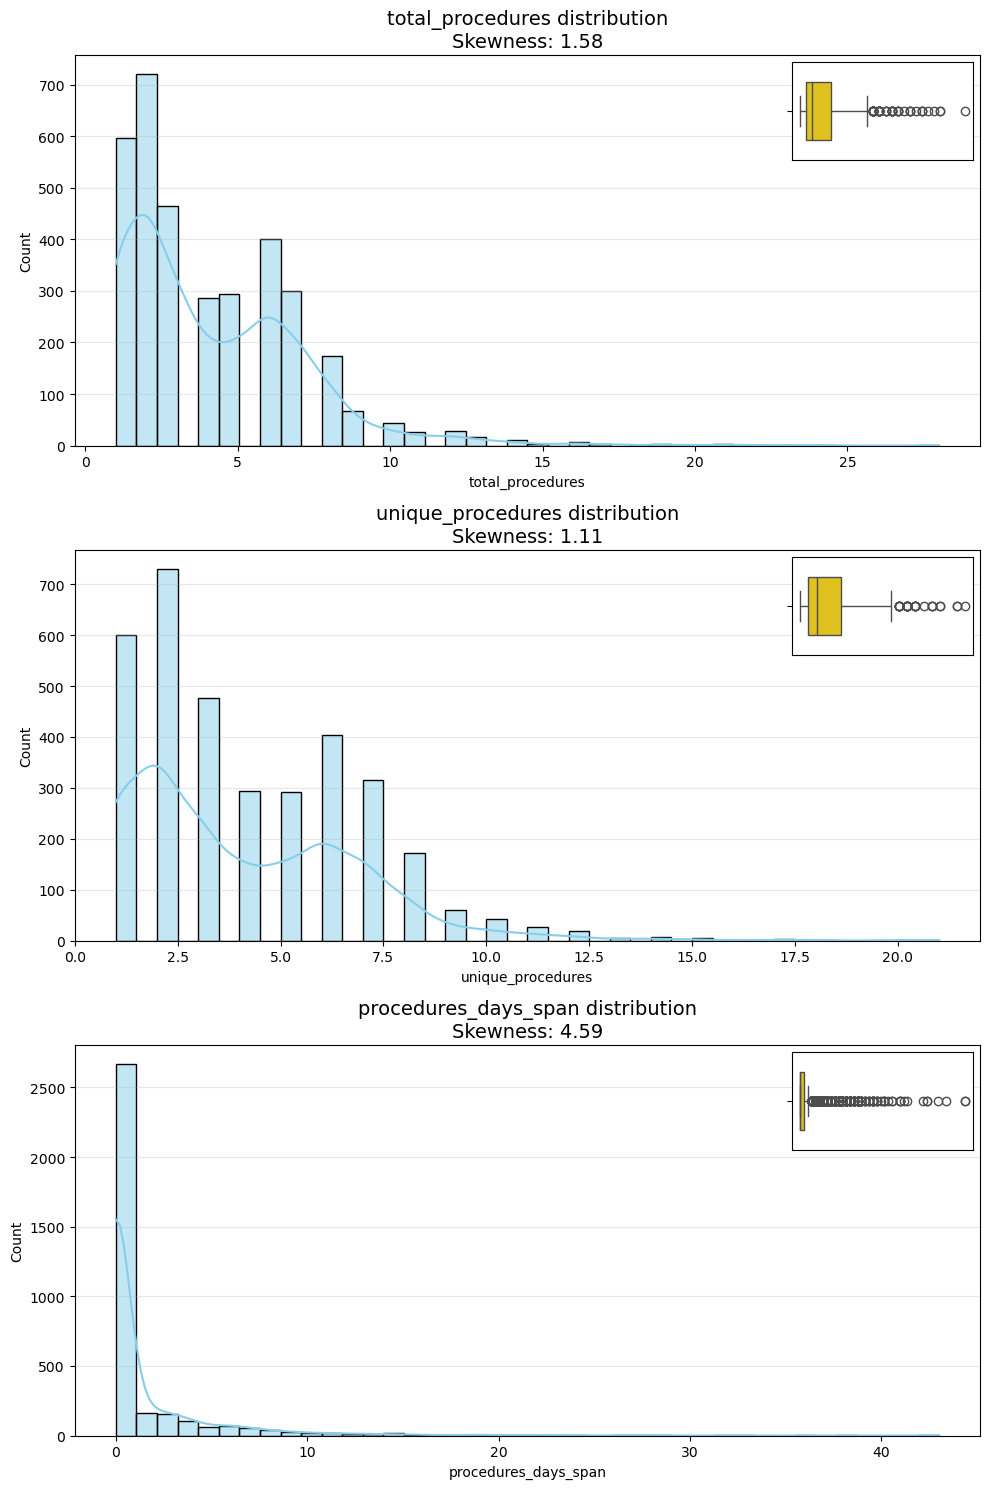

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

cols_to_check = ['total_procedures', 'unique_procedures', 'procedures_days_span']
n_plots = len(cols_to_check)

# Regola l'altezza: diamo 4-5 pollici di altezza per ogni grafico
plt.figure(figsize=(10, 5 * n_plots))

for i, col in enumerate(cols_to_check):
    # n_plots righe, 1 colonna, grafico corrente i+1
    ax = plt.subplot(n_plots, 1, i+1)
    
    # --- 1. Istogramma Principale ---
    sns.histplot(proc_features[col], kde=True, bins=40, ax=ax, color='skyblue')
    
    # Calcolo Skewness
    skew_val = proc_features[col].skew()
    ax.set_title(f"{col} distribution\nSkewness: {skew_val:.2f}", fontsize=14)
    ax.grid(axis='y', alpha=0.3) 
    
    ax_ins = inset_axes(ax, width="20%", height="25%", loc='upper right')
    sns.boxplot(x=proc_features[col], ax=ax_ins, color='gold', width=0.6)
    
    ax_ins.set_xlabel("")
    ax_ins.set_xticks([]) 

plt.tight_layout()
plt.show()


We need to correct the asymmetry of these distributions for clustering task.

In [18]:
proc_features['total_procedures'] = np.log1p(proc_features['total_procedures'])
proc_features['unique_procedures'] = np.log1p(proc_features['unique_procedures'])
proc_features['procedures_days_span'] = np.log1p(proc_features['procedures_days_span'])

In [20]:
from scipy.stats import skew
print("Skewness after transformation:")
print(f"total_procedures: {skew(proc_features['total_procedures']):.2f}")
print(f"unique_procedures: {skew(proc_features['unique_procedures']):.2f}")
print(f"procedures_days_span: {skew(proc_features['procedures_days_span']):.2f}")

Skewness after transformation:
total_procedures: 0.12
unique_procedures: 0.05
procedures_days_span: 1.60


The `procedures_days_span` distribution is still asymmetric, but we can keep it cause temporal range date are naturally asimmetric

In [19]:
proc_features.to_csv(notebook_dir.parents[1] / "1" / "Features" / "procedure_code_features.csv", index=False)